In [1]:
# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from collections import Counter

2025-10-03 18:22:44.721125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759494164.864834    6617 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759494164.908547    6617 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759494165.144747    6617 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759494165.144804    6617 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1759494165.144810    6617 computation_placer.cc:177] computation placer alr

In [4]:
# Parameters
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 10 

In [22]:
X, y, class_names = [], [], []
class_map = {}

print("[INFO] Loading dataset...")

for shape_name in os.listdir(DATA_PATH): 
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    
    for score in os.listdir(shape_path): 
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        
        label = f"{shape_name}_{score}"
        if label not in class_map:
            class_map[label] = len(class_map)
            class_names.append(label)
        
        for file in os.listdir(score_path):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                path = os.path.join(score_path, file)
                img = cv2.imread(path)
                if img is None:
                    continue
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_map[label])

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
y_cat = to_categorical(y, num_classes=len(class_map))

print(f"[INFO] Dataset loaded: {X.shape[0]} samples, {len(class_map)} classes")

[INFO] Loading dataset...
[INFO] Dataset loaded: 4298 samples, 34 classes


In [8]:
# Filter out classes with only 1 sample
counts = Counter(y)
valid_classes = [cls for cls, c in counts.items() if c > 1]

X_filtered = []
y_filtered = []
for xi, yi in zip(X, y):
    if yi in valid_classes:
        X_filtered.append(xi)
        y_filtered.append(yi)

X = np.array(X_filtered)
y = np.array(y_filtered)

# 🔹 Remap labels to start from 0
unique_classes = sorted(set(y))
class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
y_mapped = np.array([class_mapping[yi] for yi in y])

# One-hot encode with correct num_classes
y_cat = to_categorical(y_mapped, num_classes=len(unique_classes))

In [9]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

In [13]:
# Build ResNet Model
num_classes = len(np.unique(y))  

base_model = ResNet50(include_top=False, 
                      input_shape=(IMG_SIZE, IMG_SIZE, 3), 
                      weights=None)  

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │        63,519 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,651,231 (90.22 MB)

 Trainable params: 23,598,111 (90.02 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [14]:
print("Unique classes in y:", len(np.unique(y)))
print("Output layer units:", num_classes)

Unique classes in y: 31
Output layer units: 31


In [15]:
# Train
print("[INFO] Training ResNet...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

[INFO] Training ResNet...
Epoch 1/10


2025-10-03 18:35:02.110282: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 540278784 exceeds 10% of free system memory.


86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1825 - loss: 4.1052  

2025-10-03 18:39:12.028068: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 135069696 exceeds 10% of free system memory.


86/86 ━━━━━━━━━━━━━━━━━━━━ 258s 3s/step - accuracy: 0.1838 - loss: 4.0936 - val_accuracy: 0.0946 - val_loss: 5.3372
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.6162 - loss: 1.4082 - val_accuracy: 0.1194 - val_loss: 6.6537
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.7123 - loss: 0.8846 - val_accuracy: 0.1325 - val_loss: 11.3302
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.7096 - loss: 0.9052 - val_accuracy: 0.4381 - val_loss: 2.3968
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.7257 - loss: 0.8050 - val_accuracy: 0.6565 - val_loss: 1.2787
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.7372 - loss: 0.7773 - val_accuracy: 0.1892 - val_loss: 5.6807
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.7664 - loss: 0.6847 - val_accuracy: 0.1528 - val_loss: 5.9765
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.7478 - loss: 0.6951 - val_accuracy: 0.3886 - val_loss: 3

In [18]:
# Evaluate ResNet
print("\n[INFO] Evaluating ResNet...")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"[RESULT] ResNet Accuracy: {acc:.4f}")


[INFO] Evaluating ResNet...
[RESULT] ResNet Accuracy: 0.0489


In [17]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step


In [20]:
# Convert one-hot back to class indices (if needed)
y_true = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(model.predict(X_test), axis=1)

# Get all unique labels from both true and predicted
all_labels = np.unique(np.concatenate((y_true, y_pred_classes)))

# Generate classification report safely
print(classification_report(
    y_true,
    y_pred_classes,
    labels=all_labels,                             
    target_names=[class_names[i] for i in all_labels]  
))

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 353ms/step
                      precision    recall  f1-score   support

          Triangle_0       0.00      0.00      0.00         1
          Triangle_4       0.00      0.00      0.00         8
          Triangle_5       0.00      0.00      0.00       108
              Star_3       0.00      0.00      0.00        20
              Star_2       0.00      0.00      0.00         2
              Star_0       0.00      0.00      0.00         3
              Star_4       0.00      0.00      0.00        50
              Star_5       0.00      0.00      0.00        20
              Wave_3       0.00      0.00      0.00        22
              Wave_2       0.00      0.00      0.00         1
              Wave_4       0.00      0.00      0.00        87
            Circle_3       0.00      0.00      0.00        22
            Circle_2       0.00      0.00      0.00         1
            Circle_0       0.00      0.00      0.00        91
            Circle_4       

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

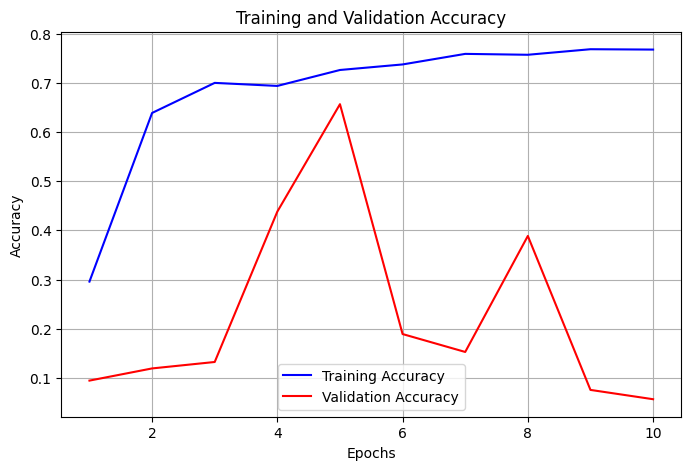

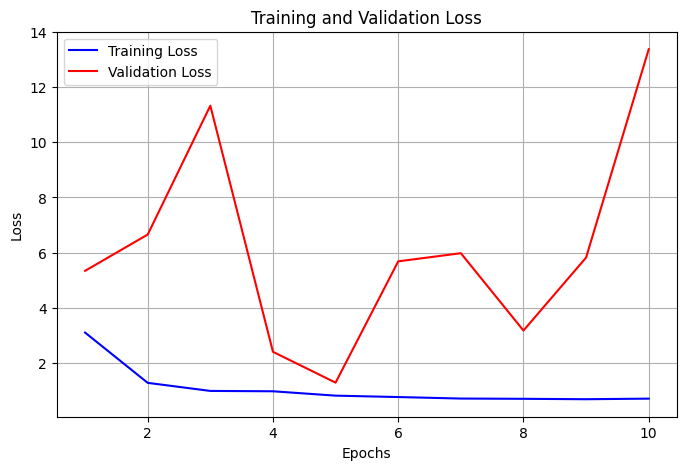

In [21]:
# Plot Accuracy & Loss
def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.show()

plot_training(history)